In [18]:
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization,AveragePooling2D
import matplotlib.pyplot as plt

In [19]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                      shear_range=0.2, 
                                        zoom_range=0.2,
                                        horizontal_flip=True)
x_train = train_datagen.flow_from_directory(
        'dataset/train',
        target_size = (32,32),
        color_mode="grayscale",
        batch_size=4,
        class_mode='binary'
        )

Found 30 images belonging to 2 classes.


In [20]:
test_datagen = ImageDataGenerator(rescale=1./255)
x_test = test_datagen.flow_from_directory(
        'dataset/test',
        target_size=(32,32),
        batch_size=4,
        color_mode="grayscale",
        class_mode='binary')

Found 30 images belonging to 2 classes.


In [21]:
def model_cnn(input_shape=(32,32,1), num_classes=1):   
    model = Sequential()
    model.add(Conv2D(32, kernel_size = (3,3), activation='tanh', input_shape = (32,32,1)))
    model.add(BatchNormalization())
    model.add(Conv2D(32, kernel_size = (3,3), activation='tanh'))
    model.add(BatchNormalization())
    model.add(Conv2D(32, kernel_size = (5,5), strides=2, padding='same', activation='tanh'))
    model.add(BatchNormalization())
    
    model.add(Conv2D(64, kernel_size = (3,3), activation='tanh'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, kernel_size = (3,3), activation='tanh'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, kernel_size = (5,5), strides=2, padding='same', activation='tanh'))
    model.add(BatchNormalization())

    model.add(Conv2D(128, kernel_size = 4, activation='tanh'))
    model.add(BatchNormalization())
    # To be able to merge into fully connected layer we have to flatten
    model.add(Flatten())
    # Lets add softmax activated neurons as much as number of classes
    model.add(Dense(1 ,activation = "sigmoid"))
    # Compile the model with loss and metrics
    model.compile(optimizer =  "adam" , loss = "binary_crossentropy", metrics=["accuracy"])
    
    return model

In [22]:
def LeNet5(input_shape=(32,32,1),num_classes=1):
    model = Sequential()
    model.add(Conv2D(4, kernel_size=(5, 5), strides=(1, 1), activation='tanh', input_shape=(32,32,1), padding="same"))
    model.add(AveragePooling2D(pool_size=(2, 2), strides=(1, 1)))
    model.add(Conv2D(8, kernel_size=(5, 5), strides=(1, 1), activation='tanh'))
    model.add(AveragePooling2D(pool_size=(2, 2), strides=(2, 2)))
    model.add(Conv2D(16, kernel_size=(5, 5), strides=(1, 1), activation='tanh'))
    model.add(Flatten())
    model.add(Dense(128, activation='tanh'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer =  "adam" , loss = "binary_crossentropy", metrics=["accuracy"])
    return model

In [23]:
model = []
model.append(model_cnn())
model.append(LeNet5())

In [24]:
models = []
for i in range(len(model)):
    r = model[i].fit(x=x_train,epochs = 25 ,validation_data = x_test)
    models.append(model[i])

Epoch 1/25
8/8 [==============================] - 2s 94ms/step - loss: 1.2977 - accuracy: 0.5000 - val_loss: 0.7026 - val_accuracy: 0.5000
Epoch 2/25
8/8 [==============================] - 1s 62ms/step - loss: 0.8741 - accuracy: 0.7667 - val_loss: 0.7567 - val_accuracy: 0.5333
Epoch 3/25
8/8 [==============================] - 0s 53ms/step - loss: 1.3354 - accuracy: 0.7000 - val_loss: 0.9440 - val_accuracy: 0.4667
Epoch 4/25
8/8 [==============================] - 0s 58ms/step - loss: 1.9556 - accuracy: 0.6667 - val_loss: 1.3422 - val_accuracy: 0.5000
Epoch 5/25
8/8 [==============================] - 0s 55ms/step - loss: 1.8936 - accuracy: 0.7333 - val_loss: 1.7083 - val_accuracy: 0.5000
Epoch 6/25
8/8 [==============================] - 0s 56ms/step - loss: 0.9791 - accuracy: 0.8000 - val_loss: 0.9351 - val_accuracy: 0.5000
Epoch 7/25
8/8 [==============================] - 0s 54ms/step - loss: 0.7972 - accuracy: 0.7667 - val_loss: 1.3423 - val_accuracy: 0.5000
Epoch 8/25
8/8 [===========

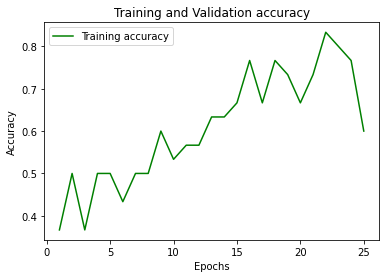

In [26]:
loss_train = r.history['accuracy']
epochs = range(1,26)
plt.plot(epochs, loss_train, 'g', label='Training accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()